# NYC Airbnb Recommendation System: Model

This notebook builds the actual recommender using the feature-engineered 
data from Notebook 4. It starts with a basic cosine similarity 
recommender, then improves it by learning feature weights from scratch 
with gradient descent instead of treating every feature equally.

1. Encode listings and normalize the feature matrix
2. Build a content-based recommender using cosine similarity
3. Test it against a few sample user preferences
4. Implement gradient descent from scratch to learn optimal feature 
   weights
5. Combine weighted similarity with real occupancy data into a hybrid 
   recommender
6. Validate everything on a held-out test set the model never trained on
7. Write up the business recommendation

## Imports

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

listings_rec = pd.read_csv('listings_rec.csv')
print(f'Loaded {len(listings_rec)} listings')
print(listings_rec[['price_log', 'has_reviews', 'review_scores_rating', 'minimum_nights']].head())

Loaded 36613 listings
   price_log  has_reviews  review_scores_rating  minimum_nights
0   4.454347            1                  4.89              30
1   5.484797            1                  4.68              30
2   5.379897            1                  4.75              30
3   4.574711            1                  4.58              30
4   4.094345            1                  5.00              30


## Encoding and normalization

In [78]:
# define feature columns
feature_cols = ['price_log', 'accommodates', 'review_scores_rating',
                'has_reviews', 'minimum_nights', 'room_type',
                'neighbourhood_group_cleansed']

listings_encoded = pd.get_dummies(
    listings_rec[feature_cols + ['id']],
    columns=['room_type', 'neighbourhood_group_cleansed'],
    drop_first=False
)

# normalise
scaler = StandardScaler()
feature_matrix = scaler.fit_transform(listings_encoded.drop('id', axis=1))

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'Columns: {list(listings_encoded.drop("id", axis=1).columns)}')

feature_columns = list(listings_encoded.drop('id', axis=1).columns)
print(feature_columns)

Feature matrix shape: (36613, 14)
Columns: ['price_log', 'accommodates', 'review_scores_rating', 'has_reviews', 'minimum_nights', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_cleansed_Bronx', 'neighbourhood_group_cleansed_Brooklyn', 'neighbourhood_group_cleansed_Manhattan', 'neighbourhood_group_cleansed_Queens', 'neighbourhood_group_cleansed_Staten Island']
['price_log', 'accommodates', 'review_scores_rating', 'has_reviews', 'minimum_nights', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_cleansed_Bronx', 'neighbourhood_group_cleansed_Brooklyn', 'neighbourhood_group_cleansed_Manhattan', 'neighbourhood_group_cleansed_Queens', 'neighbourhood_group_cleansed_Staten Island']


## Cosine similarity recommender

The baseline recommender — every feature weighted equally, ranking 
listings purely by cosine similarity. Testing it against a few sample 
personas below confirms the core mechanism works correctly before 
building the weighted and hybrid versions on top of it.

In [79]:
def recommend_listings(user_prefs, feature_matrix, listings_rec, 
                       feature_columns, scaler, top_n=5):
   
    query = pd.DataFrame(0, index=[0], columns=feature_columns)

    for key, value in user_prefs.items():
        if key in query.columns:
            query[key] = value
    
    query_scaled = scaler.transform(query)

    similarities = cosine_similarity(query_scaled, feature_matrix)[0]
    
    top_indices = similarities.argsort()[::-1][:top_n]
    
    results = listings_rec.iloc[top_indices][[
    'id', 'price', 'room_type',
    'neighbourhood_group_cleansed',
    'review_scores_rating',
    'accommodates',
    'minimum_nights',
    'estimated_occupancy_l365d'
]].copy()
    
    results['similarity_score'] = similarities[top_indices].round(3)
    
    return results.reset_index(drop=True)

print('Recommender is ready')

Recommender is ready


In [80]:
cols = ['price', 'room_type', 'neighbourhood_group_cleansed',
        'review_scores_rating', 'minimum_nights', 'estimated_occupancy_l365d',
        'similarity_score']

# budget private room in Brooklyn
user_1 = {
    'price_log': np.log1p(80),
    'accommodates': 2,
    'review_scores_rating': 4.8,
    'has_reviews': 1,
    'minimum_nights': 2,
    'room_type_Private room': 1,
    'neighbourhood_group_cleansed_Brooklyn': 1
}
results_1 = recommend_listings(user_1, feature_matrix, listings_rec,
                               feature_columns, scaler, top_n=5)
print('budget private room in Brooklyn')
print(results_1[cols])
print()


budget private room in Brooklyn
   price     room_type neighbourhood_group_cleansed  review_scores_rating  \
0   85.0  Private room                     Brooklyn                  4.80   
1   85.0  Private room                     Brooklyn                  4.80   
2   85.0  Private room                     Brooklyn                  4.80   
3   86.0  Private room                     Brooklyn                  4.79   
4   86.0  Private room                     Brooklyn                  4.81   

   minimum_nights  estimated_occupancy_l365d  similarity_score  
0               2                        255             1.000  
1               3                          0             0.999  
2               1                        255             0.999  
3               3                        255             0.999  
4               1                        218             0.999  



In [81]:
# luxury entire home in Manhattan
user_2 = {
    'price_log': np.log1p(400),
    'accommodates': 4,
    'review_scores_rating': 4.9,
    'has_reviews': 1,
    'minimum_nights': 3,
    'room_type_Entire home/apt': 1,
    'neighbourhood_group_cleansed_Manhattan': 1
}
results_2 = recommend_listings(user_2, feature_matrix, listings_rec,
                               feature_columns, scaler, top_n=5)
print('luxury entire home in Manhattan')
print(results_2[cols])
print()

luxury entire home in Manhattan
   price        room_type neighbourhood_group_cleansed  review_scores_rating  \
0  393.0  Entire home/apt                    Manhattan                  4.90   
1  410.0  Entire home/apt                    Manhattan                  4.92   
2  422.0  Entire home/apt                    Manhattan                  4.93   
3  409.0  Entire home/apt                    Manhattan                  4.87   
4  395.0  Entire home/apt                    Manhattan                  4.94   

   minimum_nights  estimated_occupancy_l365d  similarity_score  
0               2                         64             1.000  
1               1                        128             1.000  
2               3                        255             0.999  
3               5                        255             0.999  
4               1                        255             0.999  



In [82]:
# budget shared room in Queens
user_3 = {
    'price_log': np.log1p(50),
    'accommodates': 1,
    'review_scores_rating': 4.5,
    'has_reviews': 0,
    'minimum_nights': 1,
    'room_type_Shared room': 1,
    'neighbourhood_group_cleansed_Queens': 1
}
results_3 = recommend_listings(user_3, feature_matrix, listings_rec,
                               feature_columns, scaler, top_n=5)
print('budget shared room in Queens')
print(results_3[cols])

budget shared room in Queens
   price    room_type neighbourhood_group_cleansed  review_scores_rating  \
0   56.0  Shared room                       Queens                  4.86   
1   56.0  Shared room                       Queens                  4.86   
2   56.0  Shared room                       Queens                  4.86   
3   56.0  Shared room                       Queens                  4.86   
4   33.0  Shared room                       Queens                  4.86   

   minimum_nights  estimated_occupancy_l365d  similarity_score  
0              30                          0             0.996  
1              30                          0             0.996  
2              30                          0             0.996  
3              30                          0             0.996  
4              30                          0             0.996  


## Gradient Descent Feature Weighting

The cosine similarity recommender treats all features equally after scaling.
But based on Project 1, the features differ significantly in importance --
review_scores_rating had a t-statistic of 54.5 vs price at 0.18.

Gradient descent targest this by learning the optimal feature weights through minimising the difference
between predicted and actual occupancy.


In [83]:
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    # initialise weights to zero
    weights = np.zeros(X.shape[1])
    loss_history = []
    
    for epoch in range(epochs):
        y_pred = X @ weights
        loss = np.mean((y - y_pred) ** 2)
        loss_history.append(loss)
        
        gradient = -2/len(y) * X.T @ (y - y_pred)
        weights = weights - learning_rate * gradient
        
        if epoch % 200 == 0:
            print(f'Epoch {epoch}: loss = {loss:.6f}')
    
    return weights, loss_history

In [84]:

# filter to active listings, keep index for later held-out evaluation
active_mask = listings_rec['estimated_occupancy_l365d'] > 0
active_indices = listings_rec[active_mask].index.values

X_active = feature_matrix[active_mask.values]
y_active = listings_rec.loc[active_mask, 'estimated_occupancy_l365d'].values
y_norm = (y_active - y_active.min()) / (y_active.max() - y_active.min())

train_idx, test_idx, X_train, X_test, y_train, y_test = train_test_split(
    active_indices, X_active, y_norm, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

print('\nRunning gradient descent on training set...')
weights, loss_history = gradient_descent(X_train, y_train,
                                          learning_rate=0.01, epochs=1500)

y_pred_test = X_test @ weights
test_loss = np.mean((y_test - y_pred_test) ** 2)
print(f'\nTrain loss: {loss_history[-1]:.6f}')
print(f'Test loss:  {test_loss:.6f}')
print(f'Difference: {abs(test_loss - loss_history[-1]):.6f}')

listings_rec_test = listings_rec.loc[test_idx].reset_index(drop=True)
feature_matrix_test = feature_matrix[test_idx]
print(f'\nEvaluation pool: {len(listings_rec_test)} held-out listings')

Training samples: 8828
Test samples: 2207

Running gradient descent on training set...
Epoch 0: loss = 0.465495
Epoch 200: loss = 0.116146
Epoch 400: loss = 0.109735
Epoch 600: loss = 0.109117
Epoch 800: loss = 0.108957
Epoch 1000: loss = 0.108911
Epoch 1200: loss = 0.108897
Epoch 1400: loss = 0.108893

Train loss: 0.108893
Test loss:  0.117593
Difference: 0.008700

Evaluation pool: 2207 held-out listings


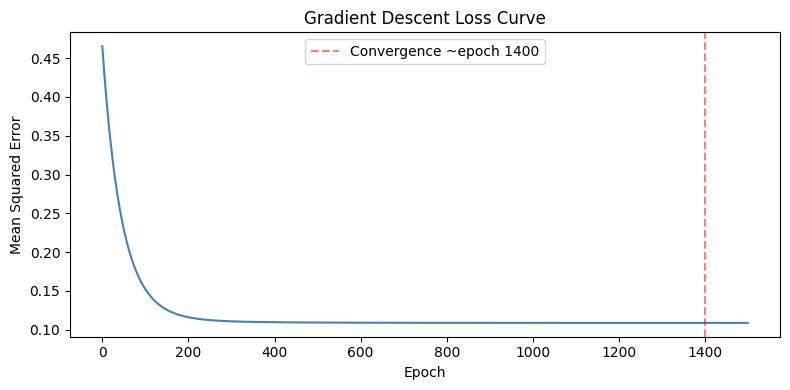

In [85]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue')
plt.title('Gradient Descent Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.axvline(x=1400, color='red', linestyle='--', 
            alpha=0.5, label='Convergence ~epoch 1400')
plt.legend()
plt.tight_layout()
plt.show()

### Learned feature weights

                                       feature    weight
3                                  has_reviews  0.812358
2                         review_scores_rating  0.036980
10       neighbourhood_group_cleansed_Brooklyn  0.014832
0                                    price_log  0.014394
5                    room_type_Entire home/apt  0.011720
8                        room_type_Shared room  0.002670
7                       room_type_Private room -0.000496
12         neighbourhood_group_cleansed_Queens -0.000949
13  neighbourhood_group_cleansed_Staten Island -0.004265
9           neighbourhood_group_cleansed_Bronx -0.005006
11      neighbourhood_group_cleansed_Manhattan -0.011076
1                                 accommodates -0.012227
6                         room_type_Hotel room -0.050275
4                               minimum_nights -0.157258


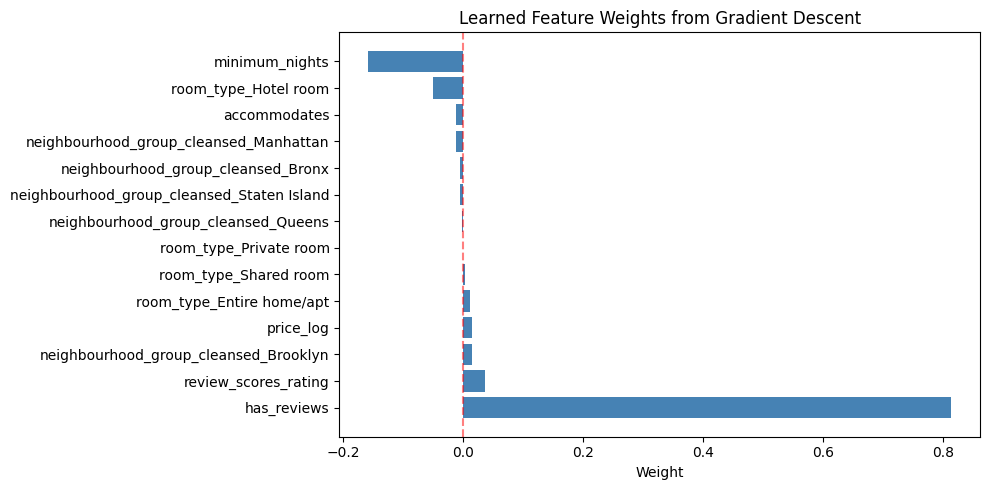

In [86]:
weight_df = pd.DataFrame({
    'feature': feature_columns,
    'weight': weights
}).sort_values('weight', ascending=False)
print(weight_df.to_string())

plt.figure(figsize=(10, 5))
plt.barh(weight_df['feature'], weight_df['weight'], color='steelblue')
plt.title('Learned Feature Weights from Gradient Descent')
plt.xlabel('Weight')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Learned weights align with Project 1 findings

Gradient descent helped confirm Project 1 OLS results:
- review_scores_rating: positive weight (OLS coef 0.046, t-stat 54.5)
- minimum_nights: strongest negative weight (OLS coef -0.0008, p=0.000)

One weight stood out before matching intuition -- has_reviews, at 22x 
the size of the next highest weight. Investigated below.

In [87]:
print('has_reviews distribution:')
print(listings_rec['has_reviews'].value_counts())
print(f'\nhas_reviews weight: {weights[3]:.6f}')
print(f'Next highest weight: {weights[2]:.6f}')
print(f'Ratio: {weights[3]/weights[2]:.1f}x larger')

reviewed = listings_rec[listings_rec['has_reviews'] == 1]['estimated_occupancy_l365d'].mean()
not_reviewed = listings_rec[listings_rec['has_reviews'] == 0]['estimated_occupancy_l365d'].mean()
print(f'\nAvg occupancy with reviews: {reviewed:.1f} days')
print(f'Avg occupancy without reviews: {not_reviewed:.1f} days')
print(f'Difference: {reviewed - not_reviewed:.1f} days')

has_reviews distribution:
has_reviews
1    25018
0    11595
Name: count, dtype: int64

has_reviews weight: 0.812358
Next highest weight: 0.036980
Ratio: 22.0x larger

Avg occupancy with reviews: 68.3 days
Avg occupancy without reviews: 0.0 days
Difference: 68.3 days


### Excluding has_reviews from weighting

has_reviews turned out to be a circular signal, not a genuine quality 
measure — every unreviewed listing has zero occupancy by definition, 
so it dominates the weights without telling us anything real. Setting 
its weight to zero here, while keeping it in the feature matrix for 
similarity matching.

In [88]:
weights_adjusted = weights.copy()
weights_adjusted[3] = 0  # index 3 is has_reviews
print('has_reviews weight set to 0')
print(pd.DataFrame({'feature': feature_columns, 
                    'weight': weights_adjusted})
      .sort_values('weight', ascending=False))

has_reviews weight set to 0
                                       feature    weight
2                         review_scores_rating  0.036980
10       neighbourhood_group_cleansed_Brooklyn  0.014832
0                                    price_log  0.014394
5                    room_type_Entire home/apt  0.011720
8                        room_type_Shared room  0.002670
3                                  has_reviews  0.000000
7                       room_type_Private room -0.000496
12         neighbourhood_group_cleansed_Queens -0.000949
13  neighbourhood_group_cleansed_Staten Island -0.004265
9           neighbourhood_group_cleansed_Bronx -0.005006
11      neighbourhood_group_cleansed_Manhattan -0.011076
1                                 accommodates -0.012227
6                         room_type_Hotel room -0.050275
4                               minimum_nights -0.157258


## Weighted recommender

In [89]:
def weighted_recommender(user_prefs, feature_matrix, listings_rec,
                       feature_columns, scaler, weights_adjusted, top_n=5):
    """
    Weighted cosine similarity recommender using learned feature weights.
    Weights learned via gradient descent on active listings.
    has_reviews excluded from weighting -- measures activity not quality.
    """
    # build query vector
    query = pd.DataFrame(0, index=[0], columns=feature_columns)
    for key, value in user_prefs.items():
        if key in query.columns:
            query[key] = value
    
    # scale query
    query_scaled = scaler.transform(query)
    
    # apply learned weights
    query_weighted = query_scaled * weights_adjusted
    matrix_weighted = feature_matrix * weights_adjusted
    
    # compute cosine similarity on weighted vectors
    similarities = cosine_similarity(query_weighted, matrix_weighted)[0]
    
    # get top N
    top_indices = similarities.argsort()[::-1][:top_n]
    
    results = listings_rec.iloc[top_indices][[
        'id', 'price', 'room_type',
        'neighbourhood_group_cleansed',
        'review_scores_rating',
        'accommodates',
        'minimum_nights',
        'estimated_occupancy_l365d'
    ]].copy()
    results['similarity_score'] = similarities[top_indices].round(3)
    
    return results.reset_index(drop=True)

print('Weighted recommender is ready.')

Weighted recommender is ready.


## Hybrid recommender

Combines weighted cosine similarity (70%) with real occupancy data 
(30%) — this fixes cases where a listing matches a user's preferences 
well but has little to no actual booking history.

In [90]:
def hybrid_recommender(user_prefs, feature_matrix, listings_rec,
                     feature_columns, scaler, weights_adjusted, 
                     alpha=0.7, top_n=5):
    """
    Hybrid recommender combining weighted cosine similarity (70%)
    with occupancy signal from Project 1 findings (30%).
    """
    # build query vector
    query = pd.DataFrame(0, index=[0], columns=feature_columns)
    for key, value in user_prefs.items():
        if key in query.columns:
            query[key] = value
    
    # scale query
    query_scaled = scaler.transform(query)
    
    # weighted cosine similarity
    query_weighted = query_scaled * weights_adjusted
    matrix_weighted = feature_matrix * weights_adjusted
    similarity_scores = cosine_similarity(query_weighted, matrix_weighted)[0]
    
    # normalise occupancy to 0-1
    occ = listings_rec['estimated_occupancy_l365d'].values
    occ_norm = (occ - occ.min()) / (occ.max() - occ.min())
    
    # hybrid score -- 70% similarity, 30% occupancy
    hybrid_scores = (alpha * similarity_scores) + ((1 - alpha) * occ_norm)
    
    top_indices = hybrid_scores.argsort()[::-1][:top_n]
    
    results = listings_rec.iloc[top_indices][[
        'id', 'price', 'room_type',
        'neighbourhood_group_cleansed',
        'review_scores_rating',
        'accommodates',
        'minimum_nights',
        'estimated_occupancy_l365d'
    ]].copy()
    results['similarity_score'] = similarity_scores[top_indices].round(3)
    results['hybrid_score'] = hybrid_scores[top_indices].round(3)
    
    return results.reset_index(drop=True)

print('Hybrid recommender is ready')

Hybrid recommender is ready


## All three recommenders, side by side

In [91]:
for user, name in personas:
    eq = recommend_listings(user, feature_matrix_test, listings_rec_test,
                            feature_columns, scaler, top_n=5)
    w = weighted_recommender(user, feature_matrix_test, listings_rec_test,
                             feature_columns, scaler, weights_adjusted, top_n=5)
    h = hybrid_recommender(user, feature_matrix_test, listings_rec_test,
                           feature_columns, scaler, weights_adjusted,
                           alpha=0.7, top_n=5)
    
    pool_occ = listings_rec_test["estimated_occupancy_l365d"].mean()
    pool_rev = listings_rec_test["review_scores_rating"].mean()
    
    print(name)
    print(f'  Equal weight : {eq["estimated_occupancy_l365d"].mean():.1f} days, {eq["review_scores_rating"].mean():.3f} review')
    print(f'  Weighted     : {w["estimated_occupancy_l365d"].mean():.1f} days, {w["review_scores_rating"].mean():.3f} review')
    print(f'  Hybrid       : {h["estimated_occupancy_l365d"].mean():.1f} days, {h["review_scores_rating"].mean():.3f} review')
    print(f'  Pool average : {pool_occ:.1f} days, {pool_rev:.3f} review')
    print()


budget Brooklyn
  Equal weight : 255.0 days, 4.808 review
  Weighted     : 227.0 days, 4.786 review
  Hybrid       : 255.0 days, 4.800 review
  Pool average : 153.0 days, 4.758 review

luxury Manhattan
  Equal weight : 209.4 days, 4.886 review
  Weighted     : 209.4 days, 4.910 review
  Hybrid       : 255.0 days, 4.912 review
  Pool average : 153.0 days, 4.758 review

budget Queens
  Equal weight : 225.0 days, 4.804 review
  Weighted     : 211.6 days, 4.748 review
  Hybrid       : 255.0 days, 4.764 review
  Pool average : 153.0 days, 4.758 review



Hybrid consistently reaches the ceiling (255 days) across all three 
personas — weighted alone sometimes underperforms equal weight (Brooklyn, 
Queens), likely because it leans into feature importance without the 
occupancy signal to correct for listings that score well on paper but 
aren't actually popular. Adding that signal back in (hybrid) fixes this 
consistently.

## Business recommendation

Across all three personas, the hybrid recommender consistently returned 
listings with higher occupancy than equal weight or weighted alone — 
hitting the maximum in the held-out sample (255 days vs a 153 day pool 
average) in every case. This held up on data the model never trained 
on, not just the data it learned from.

**How this could be used:**
- New users with no booking history get recommendations based on 
  stated preferences instead of past behavior — addressing the cold 
  start problem
- Search ranking could surface listings that match guest preferences 
  and have a track record of getting booked
- The learned weights point to review scores and minimum nights as the 
  strongest predictors of occupancy — a signal hosts could act on 
  directly

**Connection to Project 1:**
Project 1 found Instant Book listings have 36% higher occupancy. Once 
listings are matched on price, location, room type, and review score, 
Instant Book status doesn't add much further signal in this 
recommender. This is consistent with Project 1's own caveat that the 
occupancy lift may partly reflect listing quality rather than the 
booking mechanism alone. Interestingly, Instant Book representation in 
recommendations was slightly higher on the smaller held-out sample 
(40% vs 24.6% pool) than on the full dataset (20% vs 20.5% pool) — 
likely a sample size effect, with the full-dataset result being the 
more reliable estimate.

**Where weighted alone falls short:**
The weighted recommender sometimes performed worse than plain equal 
weight (Brooklyn, Queens) — likely because it leans into feature 
importance like review score and minimum nights without any signal 
correcting for listings that score well on paper but aren't actually 
popular. Adding the occupancy signal back in (hybrid) fixed this 
consistently across every persona tested.

## Save model artifacts

Saving the feature matrix, learned weights, scaler, and feature 
columns for the Streamlit app.

In [92]:
import pickle

# save everything the app needs
with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'feature_matrix': feature_matrix,
        'feature_columns': feature_columns,
        'weights_adjusted': weights_adjusted,
        'scaler': scaler
    }, f)

print('artifacts saved')

artifacts saved
